<h1 style="
    text-align: center;
    color:  #0072bc 
;
    font-family: Georgia;
    font-size: 36px;
    font-weight: bold;
">
   Top 1000 Companies Analysis (EDA)

<p style="
    text-align: center;
    color: #FFFFFF;
    font-family: Arial;
    font-size: 16px;
"> 
    Source : Ambitionbox.com

</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
# upload dataset into DataFrame
df = pd.read_csv("ambitionbox_top_companies.csv")

In [36]:
df.drop(columns = "Unnamed: 0", inplace = True)

In [38]:
df.drop(columns = "critically_rated", inplace = True)

In [39]:
df

,name,rating,review,salary,job,highly_rated,sector,location
0,TCS,3.2,1.2L,10.5L,4.1k,Promotions,IT Services & Consulting,Bengaluru
1,Accenture,3.7,79.6k,7.4L,14.9k,Promotions,IT Services & Consulting,Bengaluru
2,Wipro,3.6,69.9k,4.9L,6,Promotions,IT Services & Consulting,Hyderabad
3,Cognizant,3.7,66k,6.1L,782,Promotions,IT Services & Consulting,Hyderabad
4,Capgemini,3.6,58k,5L,2k,Work Life Balance,IT Services & Consulting,Bengaluru
...,...,...,...,...,...,...,...,...
995,Skipper,3.8,1.2k,3.4k,6,Promotions,Industrial Machinery,Kolkata
996,Thermo,3.8,1.2k,7.1k,160,Work Life Balance,Biotechnology,Bengaluru
997,Zudio,3.9,1.2k,2.4k,--,Job Security,Retail,New Delhi
998,Writer,3.2,1.2k,3.8k,3,Promotions,BPO,Mumbai


In [40]:

#  Cheking detailed information about data using info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          999 non-null    object 
 1   rating        999 non-null    float64
 2   review        1000 non-null   object 
 3   salary        1000 non-null   object 
 4   job           1000 non-null   object 
 5   highly_rated  999 non-null    object 
 6   sector        1000 non-null   object 
 7   location      999 non-null    object 
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


### Insights : 
data has 1000 rows and 8 colums , with one numerical column and 7 categorical column

### Problem :
few columns should be numeric columns like (review,salary,job)

In [ ]:
# why this problem occur bcz (salary, review, job) column value contain dot and alphabet
# handle above problem

In [41]:

def  convert_into_float(df,column):
    v=[]
    for i in df[column]:
        if "L" in i :
            sal=i.replace("L","")
            salary=float(sal)*100000
            v.append(salary)

        elif "k" in i :
            sal=i.replace("k","")
            salary=float(sal)*1000
            v.append(salary)
        elif i.isdigit():
            v.append(float(i))
        elif i.isdigit():
          v.append(float(i))
        else:
            v.append(np.nan)
    df[column]=v

In [42]:
convert_into_float(df,"salary")
convert_into_float(df,"job")
convert_into_float(df,"review")

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          999 non-null    object 
 1   rating        999 non-null    float64
 2   review        999 non-null    float64
 3   salary        999 non-null    float64
 4   job           856 non-null    float64
 5   highly_rated  999 non-null    object 
 6   sector        1000 non-null   object 
 7   location      999 non-null    object 
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [44]:
df.head(10)

,name,rating,review,salary,job,highly_rated,sector,location
0,TCS,3.2,120000.0,1050000.0,4100.0,Promotions,IT Services & Consulting,Bengaluru
1,Accenture,3.7,79600.0,740000.0,14900.0,Promotions,IT Services & Consulting,Bengaluru
2,Wipro,3.6,69900.0,490000.0,6.0,Promotions,IT Services & Consulting,Hyderabad
3,Cognizant,3.7,66000.0,610000.0,782.0,Promotions,IT Services & Consulting,Hyderabad
4,Capgemini,3.6,58000.0,500000.0,2000.0,Work Life Balance,IT Services & Consulting,Bengaluru
5,HDFC,3.8,57600.0,160000.0,400.0,Job Security,Banking,Mumbai
6,Infosys,3.5,52700.0,540000.0,4600.0,Job Security,IT Services & Consulting,Bengaluru
7,HCLTech,3.4,49700.0,400000.0,374.0,Promotions,IT Services & Consulting,Bengaluru
8,ICICI,4.0,48900.0,160000.0,57.0,Job Security,Banking,Mumbai
9,Tech,3.3,46900.0,290000.0,668.0,Promotions,IT Services & Consulting,Hyderabad


In [45]:

# analyze discriptive statistical information for numerical data
df.describe(include=[int,float])

,rating,review,salary,job
count,999.000000,999.000000,9.990000e+02,856.000000
mean,3.781582,4100.500501,1.816855e+04,160.275701
std,0.336195,7796.063556,5.831504e+04,718.638462
min,1.300000,1200.000000,3.000000e+00,1.000000
25%,3.600000,1500.000000,4.800000e+03,12.000000
50%,3.800000,2200.000000,7.800000e+03,33.000000
75%,4.000000,3700.000000,1.350000e+04,92.000000
max,4.900000,120000.000000,1.050000e+06,14900.000000


In [46]:
# analyze discriptive statistical information for catogorical data
df.describe(include=object)

,name,highly_rated,sector,location
count,999,999,1000,999
unique,810,7,70,69
top,Tata,Promotions,IT Services & Consulting,Bengaluru
freq,20,290,124,212


---------------------------------------------------------------------------------------------

## $Datacleaning$ -

### 1. Checking and Handeling `Null` values -

In [47]:
df.isna().sum()

name              1
rating            1
review            1
salary            1
job             144
highly_rated      1
sector            0
location          1
dtype: int64

In [49]:
from pandas.io.formats.style_render import Subset
# Replace null values with 0 , bcz if value is null that mean there are no opning for jobs
df['job'].fillna(0,inplace=True)

# drop row which having null values , bcz there are very less null values
df.dropna(subset=["name","salary","highly_rated","sector","location"],inplace=True)

In [50]:
df.isna().sum()

name            0
rating          0
review          0
salary          0
job             0
highly_rated    0
sector          0
location        0
dtype: int64

### 2. Checking Duplicates -

In [51]:
df.duplicated().sum()

np.int64(1)

In [52]:
df[df.duplicated(keep=False)]

,name,rating,review,salary,job,highly_rated,sector,location
779,Worley,4.1,1500.0,7700.0,8.0,Work Life Balance,Engineering & Construction,Mumbai
780,Worley,4.1,1500.0,7700.0,8.0,Work Life Balance,Engineering & Construction,Mumbai


In [53]:
df.drop_duplicates(inplace=True)

In [54]:
df.shape

(995, 8)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 995 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          995 non-null    object 
 1   rating        995 non-null    float64
 2   review        995 non-null    float64
 3   salary        995 non-null    float64
 4   job           995 non-null    float64
 5   highly_rated  995 non-null    object 
 6   sector        995 non-null    object 
 7   location      995 non-null    object 
dtypes: float64(4), object(4)
memory usage: 70.0+ KB


### 3. Analyzing Outliers -

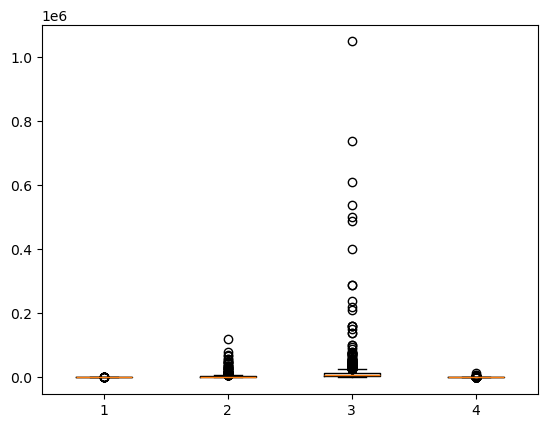

In [56]:
plt.boxplot(df.select_dtypes(include='number'))
plt.show()

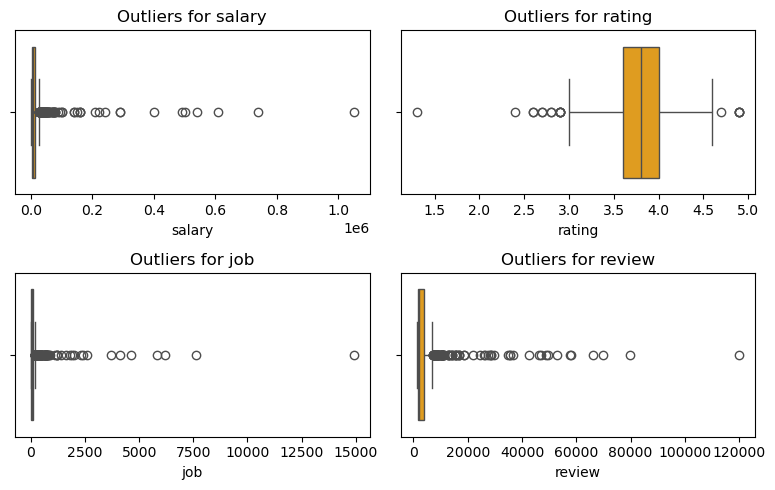

In [57]:
plt.figure(figsize=(8,5))

plt.subplot(2,2,1)
sns.boxplot(x=df["salary"],color="orange")
plt.title("Outliers for salary")

plt.subplot(2,2,2)
sns.boxplot(x=df["rating"],color="orange")
plt.title("Outliers for rating")

plt.subplot(2,2,3)
sns.boxplot(x=df["job"],color="orange")
plt.title("Outliers for job")

plt.subplot(2,2,4)
sns.boxplot(x=df["review"],color="orange")
plt.title("Outliers for review")

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------

In [58]:
df.to_csv("ambitionbox_top_companies.csv")